# Rotation-term stability across unseeded runs

Side-by-side comparison of the rotation term $1 - (\hat w_j)_j^2$ from repeated
**unseeded** runs of the Part-(ii) experiment (`random_seed=None`, nested sampling,
$n = 60$). Two views:

1. **Per p** — boxplots of the 40-replicate distribution per run at each ambient
   dimension, with each run's median traced through its own boxes as a line.
2. **Pooled over p** — since $p$ doesn't matter, pool it and put the runs directly
   next to each other: the cleanest view of run-to-run spread, which is pure
   finite-replication noise.

All panels share both axes, so the factors are directly comparable.

Data comes from `nb_outputs/rotation_runs.parquet` (written by `python rotation_runs/rotation_runs.py`);
if it's missing, the notebook simulates fresh runs in a few seconds.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "fl_experiment_setup.py").exists():
    REPO_ROOT = REPO_ROOT.parent  # notebook lives in rotation_runs/
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))  # append: keep the notebook dir first
                                     # so `import rotation_runs` finds the module

from loguru import logger
logger.remove()

import pandas as pd
import seaborn as sns

from rotation_runs import simulate_runs, plot_rotation_boxplots

DATA = REPO_ROOT / "nb_outputs" / "rotation_runs.parquet"
if DATA.exists():
    big = pd.read_parquet(DATA)
    print(f"loaded {DATA.name}: {len(big)} rows, runs={sorted(big.run.unique())}")
else:
    big = simulate_runs(n_runs=5, n_reps=40)
    print(f"simulated fresh: {len(big)} rows")

loaded rotation_runs.parquet: 4200 rows, runs=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## 1 — Boxplots with median lines at each p

Boxes: the 40-replicate rotation distribution per run at each $p$. Lines: each
run's median traced through its own boxes. With the y-axis shared across panels,
factor 1's rotation is visibly an order of magnitude below factors 2–3.

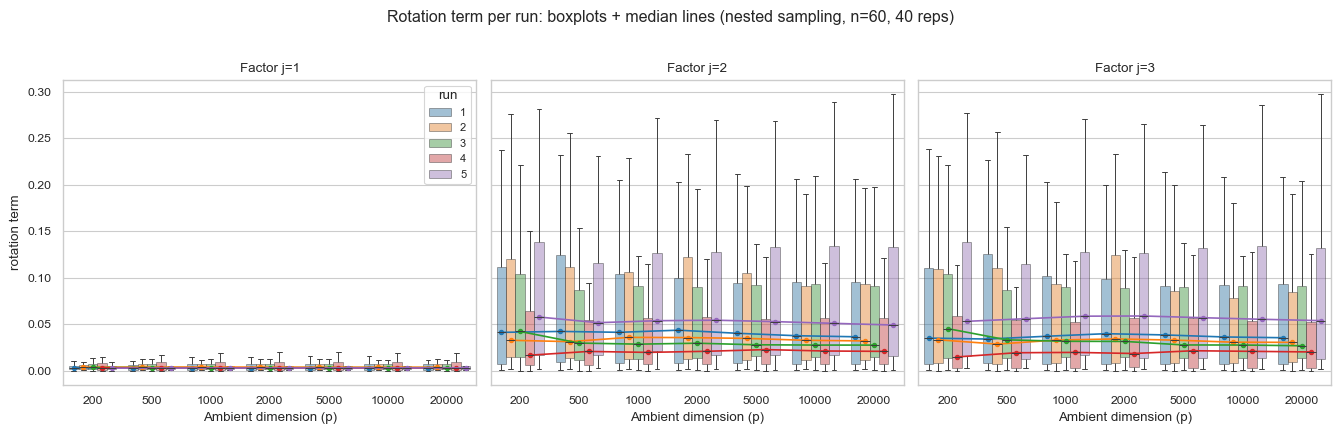

In [2]:
import matplotlib.pyplot as plt

P_ORDER = sorted(big["p"].unique())
N_RUNS = big["run"].nunique()

sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharex=True, sharey=True)
for ax, j in zip(axes, sorted(big["j"].unique())):
    sub = big[big["j"] == j]
    sns.boxplot(data=sub, x="p", y="rotation", hue="run", order=P_ORDER,
                showfliers=False, palette="tab10", ax=ax, legend=(j == 1),
                boxprops={"alpha": 0.45}, linewidth=0.7)
    sns.pointplot(data=sub, x="p", y="rotation", hue="run", order=P_ORDER,
                  estimator="median", errorbar=None, dodge=0.8 - 0.8 / N_RUNS,
                  palette="tab10", markersize=3, linewidth=1.2, ax=ax, legend=False)
    ax.set_title(f"Factor j={j}")
    ax.set_xlabel("Ambient dimension (p)")
    ax.set_ylabel("rotation term" if j == 1 else "")
axes[0].legend(title="run", fontsize=8)
fig.suptitle("Rotation term per run: boxplots + median lines "
             "(nested sampling, n=60, 40 reps)", y=1.02)
fig.tight_layout()

## 2 — Pooled over p: just the runs, grouped by factor

All $p$ values pooled (legitimate because of the $p$-invariance above), one box per
run, factors side by side. Factor 1 (the market-like factor) barely rotates;
factors 2 and 3 — with close vols (8% vs 6%) — rotate an order of magnitude more
and look nearly interchangeable.

Text(0.5, 1.06, 'Rotation term by run, all p pooled')

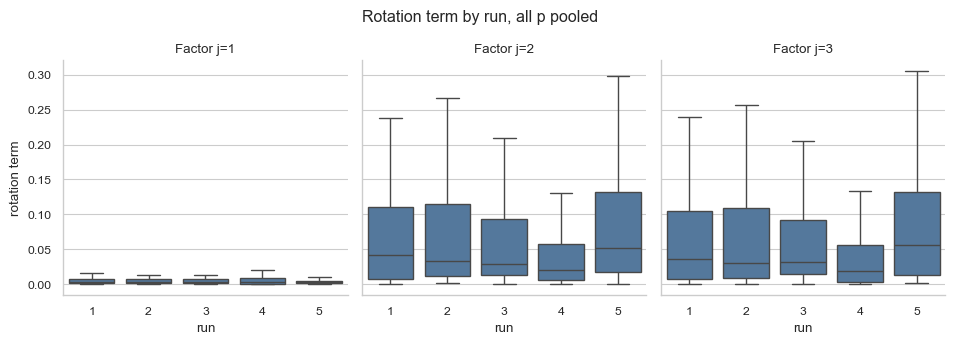

In [3]:
sns.set_theme(style="whitegrid", context="paper")
g2 = sns.catplot(
    data=big, x="run", y="rotation", col="j",
    kind="box", showfliers=False,
    height=3.2, aspect=1.0, color="#4878a8",
)
g2.set_titles(col_template="Factor j={col_name}")
g2.set_axis_labels("run", "rotation term")
g2.fig.suptitle("Rotation term by run, all p pooled", y=1.06)

## Takeaway

The rotation term is a property of the *realized factor returns at a given* $n$,
not of the cross-section: its distribution is stable in $p$ within every run, and
the differences between unseeded runs shrink with the replication count
(`python rotation_runs.py 5 200` to see them tighten).